# Model Comparison: YOLO + CLIP vs CLIP Only vs YOLO Only

This notebook compares three dangerous-fire classifiers on the same image set:

- **Model A: YOLO + CLIP**: YOLO11 first detects fire/smoke. Only YOLO-positive images are sent to CLIP. Images with no YOLO detection are treated as **not dangerous fire**.
- **Model B: CLIP only**: every image is sent directly to the same CLIP model and caption set.
- **Model C: YOLO only**: YOLO11 alone produces the dangerous-fire score from its highest fire/smoke detection confidence. Images with no YOLO detection receive score `0.0`.

The comparison focuses on avoiding false positives while still tracking false negatives so dangerous fires are not missed. It reports F1-score, F2-score, confusion-matrix counts, false-positive rate, false-negative rate, and DET curves.

## Ground-truth labels

F1-score, F2-score, and DET curves require real labels. This notebook supports either option:

1. **CSV labels** in Google Drive, with columns like `filename,label`.
2. **Folder-name labels**, where image parent folders contain words such as `dangerous`, `safe`, `looks-like-fire`, `non_fire`, or `negative`.

Positive class means **dangerous fire**. Safe fire, looks-like-fire, and no-fire images are negative.

In [1]:
# Cell 1: Mount Google Drive and configure paths
from google.colab import drive
import os, zipfile
from pathlib import Path

drive.mount('/content/drive', force_remount=True)

# Change this to the image folder you uploaded to Google Drive -> My Drive.
DRIVE_IMAGE_FOLDER = 'yolo-clip images'
DRIVE_DIR = f'/content/drive/MyDrive/{DRIVE_IMAGE_FOLDER}'

# Optional: set this to a CSV in My Drive with columns such as filename,label.
# Leave as None to infer labels from folder names.
LABELS_CSV = None
# Example:
# LABELS_CSV = '/content/drive/MyDrive/fire_labels.csv'

assert os.path.isdir(DRIVE_DIR), (
    f'Folder not found: {DRIVE_DIR}'
    f'Make sure "{DRIVE_IMAGE_FOLDER}" exists inside My Drive on Google Drive.'
)

zip_files = [f for f in os.listdir(DRIVE_DIR) if f.lower().endswith('.zip')]
if zip_files:
    EXTRACT_DIR = f'/content/{DRIVE_IMAGE_FOLDER}_extracted'
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    for zf in zip_files:
        print(f'Extracting {zf} ...')
        with zipfile.ZipFile(os.path.join(DRIVE_DIR, zf), 'r') as z:
            z.extractall(EXTRACT_DIR)
    IMAGE_DIR = EXTRACT_DIR
else:
    IMAGE_DIR = DRIVE_DIR

print(f'Image directory: {IMAGE_DIR}')

Mounted at /content/drive
Image directory: /content/drive/MyDrive/yolo-clip images


In [2]:
# Cell 2: Install dependencies
!pip install -q ultralytics scikit-learn pandas seaborn
!pip install -q git+https://github.com/openai/CLIP.git
print('Done.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
Done.


In [3]:
# Cell 3: Imports and experiment configuration
import csv
import os
import time
from pathlib import Path

import clip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import (
    DetCurveDisplay,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_fscore_support,
)
from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

YOLO_CONF_THRESHOLD = 0.25
DECISION_THRESHOLD = 0.50

MODEL_SPECS = [
    ('Model A: YOLO + CLIP', 'model_a_score'),
    ('Model B: CLIP only', 'model_b_score'),
    ('Model C: YOLO only', 'model_c_score'),
]

# Captions 1-2 are the dangerous-fire positive class.
FIRE_CAPTIONS = [
    "Flaming structure in a fenced area with debris",       # 1 -> dangerous fire
    "Building engulfed in large flames and thick smoke",    # 2 -> dangerous fire
    "Grilled meat over an open flame on a barbecue grill",  # 3 -> safe-fire
    "Gas stove with blue flame cooking",                    # 4 -> safe-fire
    "Fireworks explosion in the night sky",                 # 5 -> safe-fire
    "Campfire in a forest at dusk",                         # 6 -> safe-fire
    "Candle flame burning in a dark environment",           # 7 -> safe-fire
    "Wood-burning fireplace in a cozy living room",         # 8 -> safe-fire
    "Man exhales smoke from a lit cigarette, emitting visible white vapor", # 9 -> safe-fire
    "Sunset illuminates modern building, vibrant clouds, calm water reflecting hues", # 10 -> looks-like-fire
    "Bright streetlamps and dense smoke create a hazy atmosphere",          # 11 -> looks-like-fire
]

CAPTION_CATEGORIES = (
    ['dangerous fire']  * 2 +
    ['safe-fire']       * 7 +
    ['looks-like-fire'] * 2
)
DANGEROUS_CAPTION_INDICES = [i for i, c in enumerate(CAPTION_CATEGORIES) if c == 'dangerous fire']

OUTPUT_DIR = '/content/drive/MyDrive/model_comparison_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Device: {DEVICE.upper()}')
print(f'Outputs will be saved to: {OUTPUT_DIR}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: CUDA
Outputs will be saved to: /content/drive/MyDrive/model_comparison_outputs


In [4]:
# Cell 4: Collect images and load ground-truth labels
image_paths = sorted(
    p for p in Path(IMAGE_DIR).rglob('*')
    if p.suffix.lower() in IMAGE_EXTS
)
print(f'Found {len(image_paths)} image(s).')

# Ground-truth folder convention for this dataset:
#   yolo-clip images/A1/*  -> dangerous fire, positive class
#   yolo-clip images/B1/*  -> not dangerous fire, negative class
#   yolo-clip images/B2/*  -> not dangerous fire, negative class
#   yolo-clip images/B3/*  -> not dangerous fire, negative class
#   yolo-clip images/B4/*  -> not dangerous fire, negative class
#   yolo-clip images/B5/*  -> not dangerous fire, negative class
#   yolo-clip images/B6/*  -> not dangerous fire, negative class
#   yolo-clip images/C1/*  -> not dangerous fire, negative class
DANGEROUS_FIRE_FOLDERS = {'A1'}
NOT_DANGEROUS_FIRE_FOLDERS = {'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'C1'}
EXPECTED_LABEL_FOLDERS = DANGEROUS_FIRE_FOLDERS | NOT_DANGEROUS_FIRE_FOLDERS

POSITIVE_LABEL_WORDS = {'dangerous', 'dangerous_fire', 'dangerous fire', 'fire_dangerous', 'positive', '1', 'true'}
NEGATIVE_LABEL_WORDS = {
    'safe', 'safe_fire', 'safe-fire', 'looks-like-fire', 'looks_like_fire',
    'non_fire', 'nofire', 'no_fire', 'negative', '0', 'false'
}

def normalize_label(value):
    text = str(value).strip().lower().replace('-', '_').replace(' ', '_')
    positive = {w.replace('-', '_').replace(' ', '_') for w in POSITIVE_LABEL_WORDS}
    negative = {w.replace('-', '_').replace(' ', '_') for w in NEGATIVE_LABEL_WORDS}
    if text in positive:
        return 1
    if text in negative:
        return 0
    raise ValueError(f'Unknown label value: {value!r}. Use dangerous/positive/1 or safe/negative/0 style labels.')

def load_labels_from_csv(csv_path, paths):
    df = pd.read_csv(csv_path)
    lower_cols = {c.lower(): c for c in df.columns}
    filename_col = lower_cols.get('filename') or lower_cols.get('file') or lower_cols.get('image') or lower_cols.get('image_path') or lower_cols.get('path')
    label_col = lower_cols.get('label') or lower_cols.get('class') or lower_cols.get('category') or lower_cols.get('is_dangerous')
    if filename_col is None or label_col is None:
        raise ValueError('Labels CSV must include filename/path and label/class/category columns.')

    label_map = {}
    for _, row in df.iterrows():
        key = Path(str(row[filename_col])).name
        label_map[key] = normalize_label(row[label_col])

    missing = [p.name for p in paths if p.name not in label_map]
    if missing:
        raise ValueError(f'{len(missing)} image(s) are missing labels. Example: {missing[:5]}')
    return {p: label_map[p.name] for p in paths}

def infer_label_from_dataset_folder(img_path):
    relative_parts = img_path.relative_to(IMAGE_DIR).parts
    if len(relative_parts) < 2:
        raise ValueError(
            f'Image is not inside one of the expected label folders: {img_path}'
        )

    label_folder = relative_parts[0]
    if label_folder in DANGEROUS_FIRE_FOLDERS:
        return 1
    if label_folder in NOT_DANGEROUS_FIRE_FOLDERS:
        return 0
    raise ValueError(
        f'Unknown label folder "{label_folder}" for {img_path}. '
        f'Expected one of: {sorted(EXPECTED_LABEL_FOLDERS)}'
    )

if LABELS_CSV:
    labels = load_labels_from_csv(LABELS_CSV, image_paths)
    label_source = LABELS_CSV
else:
    labels = {p: infer_label_from_dataset_folder(p) for p in image_paths}
    label_source = 'dataset folders: A1=dangerous, B1-B6/C1=not dangerous'

y_true = np.array([labels[p] for p in image_paths], dtype=int)
label_counts = pd.Series(y_true).map({1: 'dangerous fire', 0: 'not dangerous fire'}).value_counts()
folder_counts = pd.Series([p.relative_to(IMAGE_DIR).parts[0] for p in image_paths]).value_counts().sort_index()

print(f'Labels loaded from: {label_source}')
print('Image count by folder:')
print(folder_counts)
print('Ground-truth label count:')
print(label_counts)


Found 548 image(s).
Labels loaded from: dataset folders: A1=dangerous, B1-B6/C1=not dangerous
Image count by folder:
A1    274
B1    274
Name: count, dtype: int64
Ground-truth label count:
dangerous fire        274
not dangerous fire    274
Name: count, dtype: int64


In [5]:
# Cell 5: Load YOLO11 and CLIP
WEIGHTS_PATH = '/content/fire_model.pt'
WEIGHTS_URL  = 'https://huggingface.co/leeyunjai/yolo11-firedetect/resolve/main/firedetect-11s.pt'

# Ensure a fresh download if the file is corrupted or not present
if os.path.exists(WEIGHTS_PATH):
    print('Removing potentially corrupted YOLO11 weights for re-download...')
    os.remove(WEIGHTS_PATH)

print('Downloading YOLO11 weights ...')
os.system(f'wget -q -O {WEIGHTS_PATH} {WEIGHTS_URL}')

yolo_model = YOLO(WEIGHTS_PATH)
print(f'YOLO11 loaded | classes: {yolo_model.names}')

clip_model, preprocess = clip.load('ViT-B/32', device=DEVICE)
text_tokens = clip.tokenize(FIRE_CAPTIONS).to(DEVICE)
print(f'CLIP ViT-B/32 loaded | device: {DEVICE.upper()}')

YOLO11 loaded | classes: {0: 'Fire', 1: 'Smoke'}


100%|███████████████████████████████████████| 338M/338M [00:03<00:00, 96.2MiB/s]


CLIP ViT-B/32 loaded | device: CUDA


In [6]:
# Cell 6: Shared helper functions
def run_yolo(img_path):
    results = yolo_model.predict(
        source=str(img_path),
        conf=YOLO_CONF_THRESHOLD,
        device=DEVICE,
        verbose=False,
        save=False,
    )
    result = results[0]
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return False, 0.0, result
    confs = boxes.conf.detach().cpu().numpy()
    return True, float(np.max(confs)), result

def clip_probs(img_path):
    image = preprocess(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits_per_image, _ = clip_model(image, text_tokens)
        probs = logits_per_image.softmax(dim=-1).detach().cpu().numpy()[0]
    return probs

def rank_from_probs(probs):
    ranked = sorted(
        [(i + 1, FIRE_CAPTIONS[i], CAPTION_CATEGORIES[i], float(probs[i])) for i in range(len(FIRE_CAPTIONS))],
        key=lambda x: x[3],
        reverse=True,
    )
    return ranked

def dangerous_clip_score(probs):
    return float(np.sum(probs[DANGEROUS_CAPTION_INDICES]))

def predict_from_scores(scores, threshold=DECISION_THRESHOLD):
    return (np.asarray(scores) >= threshold).astype(int)

In [7]:
# Cell 7: Run Model A, Model B, and Model C
rows = []
yolo_results_map = {}
start = time.time()

for i, img_path in enumerate(image_paths, 1):
    yolo_detected, yolo_conf, yolo_result = run_yolo(img_path)
    yolo_results_map[img_path] = yolo_result

    # Model B: CLIP-only sees every image.
    probs_b = clip_probs(img_path)
    rank_b = rank_from_probs(probs_b)
    score_b = dangerous_clip_score(probs_b)

    # Model A: YOLO gates CLIP. If YOLO finds no fire, the dangerous score is 0.
    if yolo_detected:
        probs_a = probs_b  # Same CLIP model and same image; reuse the probabilities.
        rank_a = rank_b
        clip_danger_score_a = dangerous_clip_score(probs_a)
        score_a = yolo_conf * clip_danger_score_a
    else:
        rank_a = []
        clip_danger_score_a = 0.0
        score_a = 0.0

    # Model C: YOLO-only uses the highest YOLO detection confidence as the score.
    score_c = yolo_conf if yolo_detected else 0.0

    best_a = rank_a[0] if rank_a else (None, None, 'no-yolo-fire-detected', 0.0)
    best_b = rank_b[0]
    best_c_category = 'yolo-fire-detected' if yolo_detected else 'no-yolo-fire-detected'

    rows.append({
        'path': str(img_path),
        'filename': img_path.name,
        'true_label': int(labels[img_path]),
        'true_label_name': 'dangerous fire' if labels[img_path] == 1 else 'not dangerous fire',
        'yolo_detected': bool(yolo_detected),
        'yolo_conf': yolo_conf,
        'model_a_score': score_a,
        'model_a_clip_danger_score': clip_danger_score_a,
        'model_a_best_caption_number': best_a[0],
        'model_a_best_caption': best_a[1],
        'model_a_best_category': best_a[2],
        'model_a_best_caption_score': best_a[3],
        'model_b_score': score_b,
        'model_b_best_caption_number': best_b[0],
        'model_b_best_caption': best_b[1],
        'model_b_best_category': best_b[2],
        'model_b_best_caption_score': best_b[3],
        'model_c_score': score_c,
        'model_c_best_category': best_c_category,
    })

    if i % 25 == 0 or i == len(image_paths):
        print(f'[{i}/{len(image_paths)}] elapsed: {time.time() - start:.1f}s')

results_df = pd.DataFrame(rows)
results_df.head()

[25/548] elapsed: 15.3s
[50/548] elapsed: 29.4s
[75/548] elapsed: 31.8s
[100/548] elapsed: 36.0s
[125/548] elapsed: 38.5s
[150/548] elapsed: 42.2s
[175/548] elapsed: 45.3s
[200/548] elapsed: 47.4s
[225/548] elapsed: 49.2s
[250/548] elapsed: 51.1s
[275/548] elapsed: 54.2s
[300/548] elapsed: 87.4s
[325/548] elapsed: 120.9s
[350/548] elapsed: 154.9s
[375/548] elapsed: 188.4s
[400/548] elapsed: 220.5s
[425/548] elapsed: 254.2s
[450/548] elapsed: 284.2s
[475/548] elapsed: 318.7s
[500/548] elapsed: 351.6s
[525/548] elapsed: 382.1s
[548/548] elapsed: 413.9s


,path,filename,true_label,true_label_name,yolo_detected,yolo_conf,model_a_score,model_a_clip_danger_score,model_a_best_caption_number,model_a_best_caption,model_a_best_category,model_a_best_caption_score,model_b_score,model_b_best_caption_number,model_b_best_caption,model_b_best_category,model_b_best_caption_score,model_c_score,model_c_best_category
0,/content/drive/MyDrive/yolo-clip images/A1/fir...,fire.497.png,1,dangerous fire,True,0.748954,0.742737,0.991699,2.0,Building engulfed in large flames and thick smoke,dangerous fire,0.693359,0.991699,2,Building engulfed in large flames and thick smoke,dangerous fire,0.693359,0.748954,yolo-fire-detected
1,/content/drive/MyDrive/yolo-clip images/A1/fir...,fire.498.png,1,dangerous fire,True,0.727404,0.714263,0.981934,1.0,Flaming structure in a fenced area with debris,dangerous fire,0.979004,0.981934,1,Flaming structure in a fenced area with debris,dangerous fire,0.979004,0.727404,yolo-fire-detected
2,/content/drive/MyDrive/yolo-clip images/A1/fir...,fire.5.png,1,dangerous fire,True,0.499840,0.354867,0.709961,2.0,Building engulfed in large flames and thick smoke,dangerous fire,0.627441,0.709961,2,Building engulfed in large flames and thick smoke,dangerous fire,0.627441,0.499840,yolo-fire-detected
3,/content/drive/MyDrive/yolo-clip images/A1/fir...,fire.50.png,1,dangerous fire,True,0.306788,0.303343,0.988770,2.0,Building engulfed in large flames and thick smoke,dangerous fire,0.880371,0.988770,2,Building engulfed in large flames and thick smoke,dangerous fire,0.880371,0.306788,yolo-fire-detected
4,/content/drive/MyDrive/yolo-clip images/A1/fir...,fire.51.png,1,dangerous fire,True,0.660969,0.659678,0.998047,2.0,Building engulfed in large flames and thick smoke,dangerous fire,0.972656,0.998047,2,Building engulfed in large flames and thick smoke,dangerous fire,0.972656,0.660969,yolo-fire-detected


In [8]:
# Cell 8: Evaluate F1, F2, false positives, and false negatives
def fbeta_from_precision_recall(precision, recall, beta=2.0):
    beta_squared = beta ** 2
    denominator = (beta_squared * precision) + recall
    if denominator == 0:
        return 0.0
    return (1 + beta_squared) * precision * recall / denominator

def evaluate_model(df, score_col, model_name, threshold=DECISION_THRESHOLD):
    y_true = df['true_label'].to_numpy(dtype=int)
    scores = df[score_col].to_numpy(dtype=float)
    y_pred = predict_from_scores(scores, threshold)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    f2 = fbeta_from_precision_recall(precision, recall, beta=2.0)
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0

    return {
        'model': model_name,
        'threshold': threshold,
        'f1': f1,
        'f2': f2,
        'precision': precision,
        'recall': recall,
        'false_positive_rate': fpr,
        'false_negative_rate': fnr,
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'tn': int(tn),
    }

summary_df = pd.DataFrame([
    evaluate_model(results_df, score_col, model_name)
    for model_name, score_col in MODEL_SPECS
])
summary_df

,model,threshold,f1,f2,precision,recall,false_positive_rate,false_negative_rate,tp,fp,fn,tn
0,Model A: YOLO + CLIP,0.5,0.668258,0.564061,0.965517,0.510949,0.018248,0.489051,140,5,134,269
1,Model B: CLIP only,0.5,0.844221,0.887949,0.780186,0.919708,0.259124,0.080292,252,71,22,203
2,Model C: YOLO only,0.5,0.751073,0.679348,0.911458,0.638686,0.062044,0.361314,175,17,99,257


In [9]:
# Cell 9: Threshold sweep to find best F1 and best F2 operating points
def threshold_sweep(df, score_col, model_name):
    rows = []
    for threshold in np.linspace(0.0, 1.0, 101):
        rows.append(evaluate_model(df, score_col, model_name, threshold=float(threshold)))
    return pd.DataFrame(rows)

sweep_df = pd.concat(
    [threshold_sweep(results_df, score_col, model_name) for model_name, score_col in MODEL_SPECS],
    ignore_index=True,
)

best_f1_df = (
    sweep_df
    .sort_values(['model', 'f1', 'false_positive_rate'], ascending=[True, False, True])
    .groupby('model')
    .head(1)
)

best_f2_df = (
    sweep_df
    .sort_values(['model', 'f2', 'false_negative_rate', 'false_positive_rate'], ascending=[True, False, True, True])
    .groupby('model')
    .head(1)
)

print('Best F1 thresholds:')
display(best_f1_df)
print('Best F2 thresholds:')
display(best_f2_df)

Best F1 thresholds:


,model,threshold,f1,f2,precision,recall,false_positive_rate,false_negative_rate,tp,fp,fn,tn
7,Model A: YOLO + CLIP,0.07,0.950276,0.945055,0.959108,0.941606,0.040146,0.058394,258,11,16,263
161,Model B: CLIP only,0.60,0.856153,0.882773,0.815182,0.901460,0.204380,0.098540,247,56,27,218
203,Model C: YOLO only,0.01,0.900344,0.933048,0.850649,0.956204,0.167883,0.043796,262,46,12,228


Best F2 thresholds:


,model,threshold,f1,f2,precision,recall,false_positive_rate,false_negative_rate,tp,fp,fn,tn
2,Model A: YOLO + CLIP,0.02,0.937163,0.946338,0.922261,0.952555,0.080292,0.047445,261,22,13,252
120,Model B: CLIP only,0.19,0.815152,0.907557,0.696891,0.981752,0.427007,0.018248,269,117,5,157
203,Model C: YOLO only,0.01,0.900344,0.933048,0.850649,0.956204,0.167883,0.043796,262,46,12,228


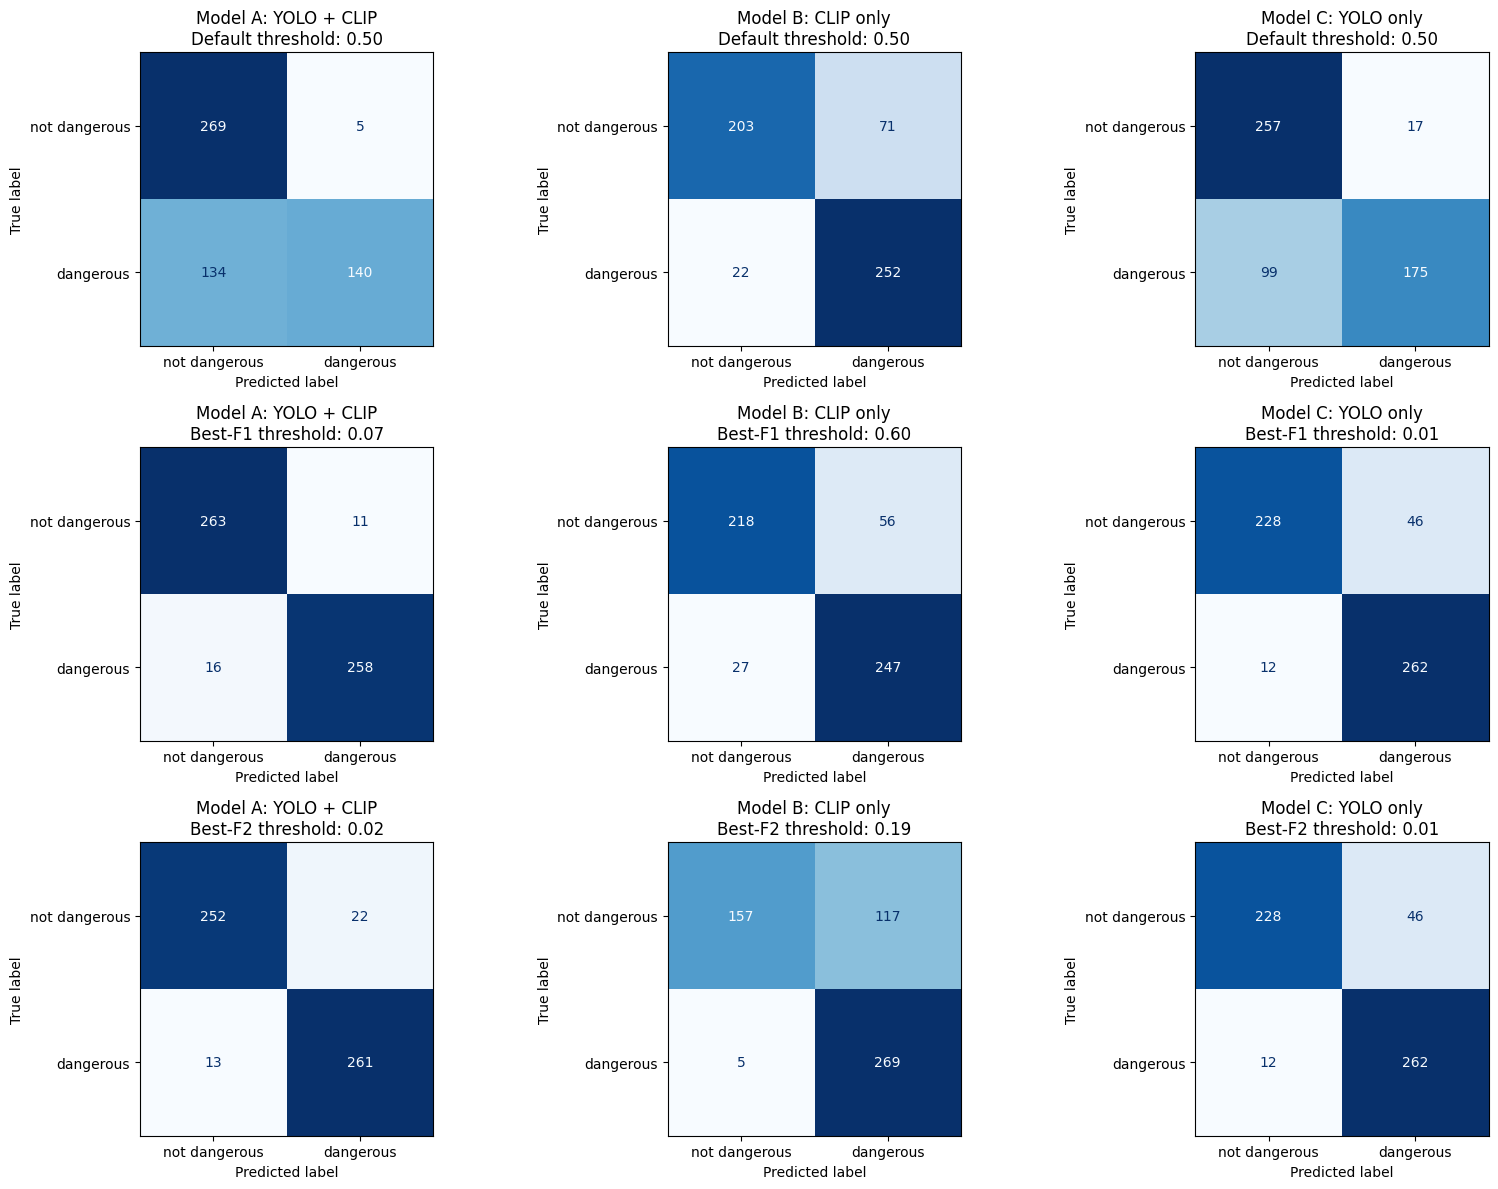

In [10]:
# Cell 10: Confusion matrices at default, best-F1, and best-F2 thresholds
def best_threshold_for_model(metric_df, model_name, metric_name):
    row = metric_df.loc[metric_df['model'] == model_name]
    if row.empty:
        raise ValueError(f'No best-{metric_name} threshold found for {model_name}. Run Cell 9 first.')
    return float(row.iloc[0]['threshold'])

threshold_sets = [
    ('Default threshold', {model_name: DECISION_THRESHOLD for model_name, _ in MODEL_SPECS}),
    ('Best-F1 threshold', {
        model_name: best_threshold_for_model(best_f1_df, model_name, 'F1')
        for model_name, _ in MODEL_SPECS
    }),
    ('Best-F2 threshold', {
        model_name: best_threshold_for_model(best_f2_df, model_name, 'F2')
        for model_name, _ in MODEL_SPECS
    }),
]

fig, axes = plt.subplots(
    nrows=len(threshold_sets),
    ncols=len(MODEL_SPECS),
    figsize=(5.5 * len(MODEL_SPECS), 12),
)
axes = np.asarray(axes).reshape(len(threshold_sets), len(MODEL_SPECS))

for row_idx, (threshold_label, thresholds) in enumerate(threshold_sets):
    for col_idx, (model_name, score_col) in enumerate(MODEL_SPECS):
        ax = axes[row_idx, col_idx]
        threshold = thresholds[model_name]
        y_pred = predict_from_scores(results_df[score_col], threshold)
        cm = confusion_matrix(results_df['true_label'], y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(cm, display_labels=['not dangerous', 'dangerous'])
        disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
        ax.set_title(f'{model_name}\n{threshold_label}: {threshold:.2f}')

plt.tight_layout()
plt.show()


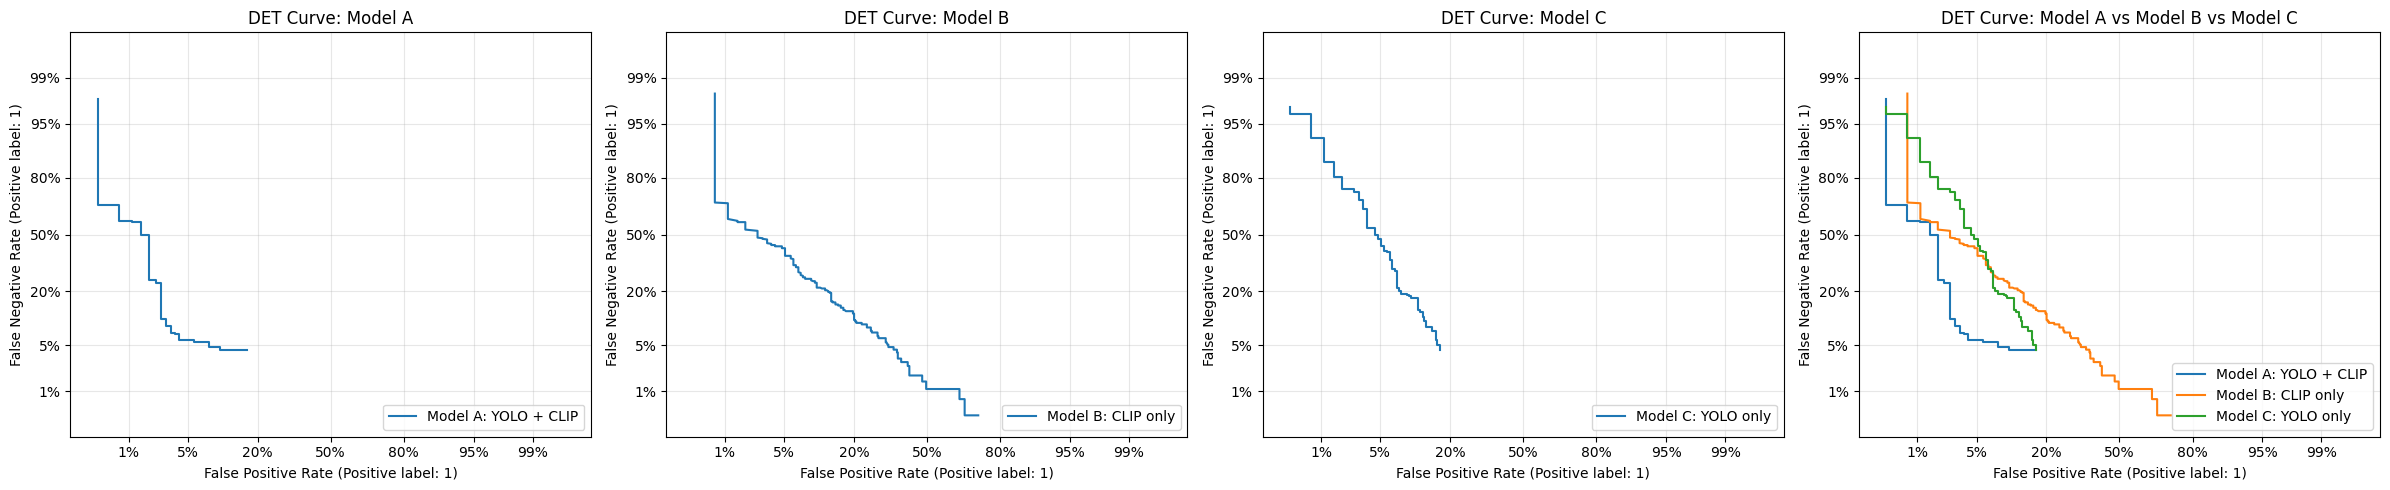

In [11]:
# Cell 11: DET curve visualizer
# DET curves show false positive rate vs false negative rate across thresholds.
# Curves closer to the bottom-left are better.
fig, axes = plt.subplots(1, len(MODEL_SPECS) + 1, figsize=(6 * (len(MODEL_SPECS) + 1), 5))
axes = np.asarray(axes).reshape(-1)

for ax, (model_name, score_col) in zip(axes[:-1], MODEL_SPECS):
    DetCurveDisplay.from_predictions(
        results_df['true_label'],
        results_df[score_col],
        name=model_name,
        ax=ax,
    )
    short_name = model_name.split(':')[0]
    ax.set_title(f'DET Curve: {short_name}')
    ax.grid(True, alpha=0.3)

combined_ax = axes[-1]
for model_name, score_col in MODEL_SPECS:
    DetCurveDisplay.from_predictions(
        results_df['true_label'],
        results_df[score_col],
        name=model_name,
        ax=combined_ax,
    )
combined_ax.set_title('DET Curve: Model A vs Model B vs Model C')
combined_ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


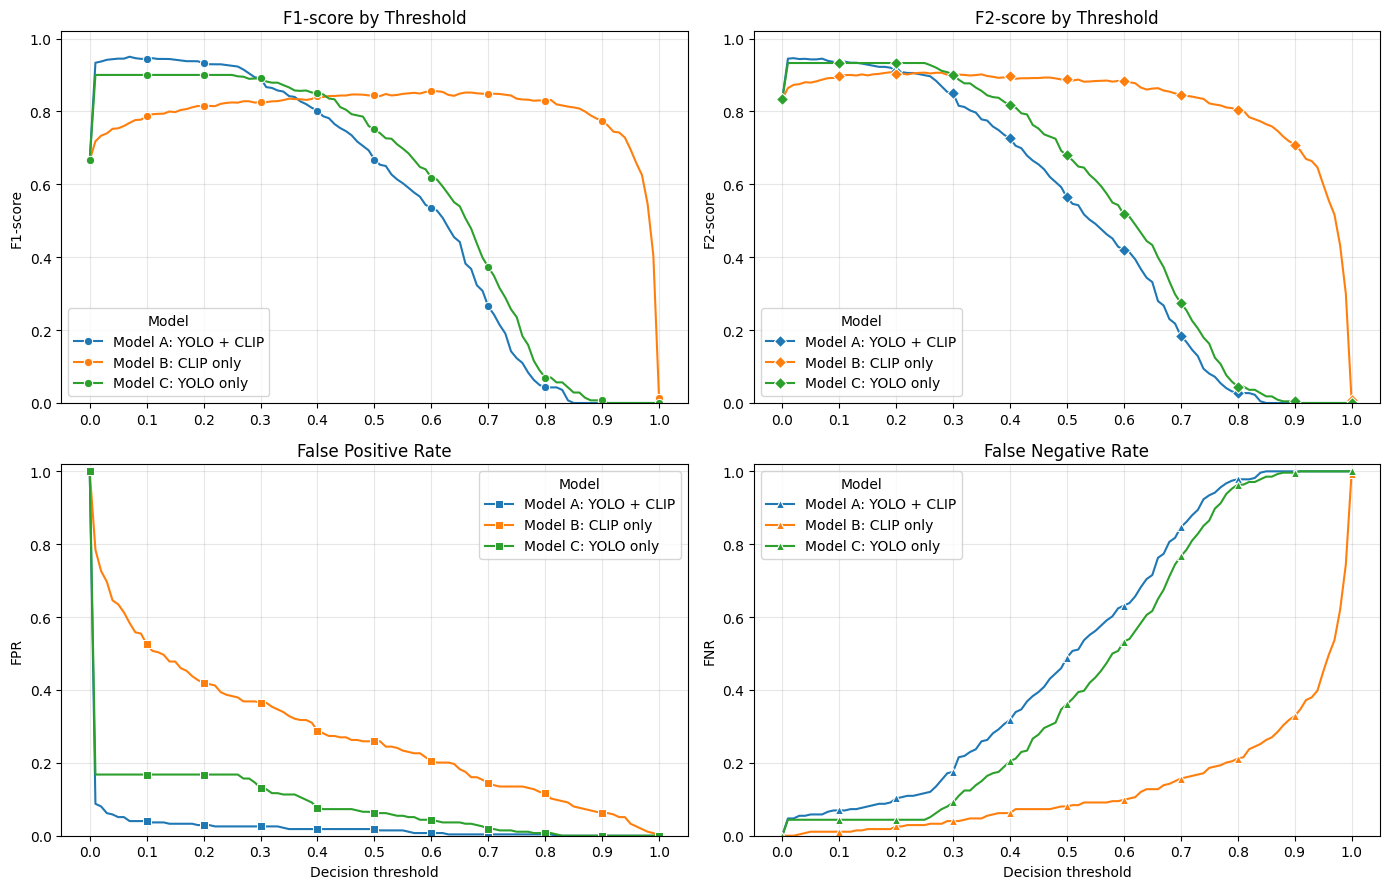

In [12]:
# Cell 12: F1, F2, and separate false-positive / false-negative tradeoff plots
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()
threshold_ticks = np.linspace(0.0, 1.0, 11)

sns.lineplot(
    data=sweep_df,
    x='threshold',
    y='f1',
    hue='model',
    marker='o',
    markevery=10,
    ax=axes[0],
)
axes[0].set_title('F1-score by Threshold')
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 1.02)
axes[0].grid(True, alpha=0.3)

sns.lineplot(
    data=sweep_df,
    x='threshold',
    y='f2',
    hue='model',
    marker='D',
    markevery=10,
    ax=axes[1],
)
axes[1].set_title('F2-score by Threshold')
axes[1].set_ylabel('F2-score')
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.3)

sns.lineplot(
    data=sweep_df,
    x='threshold',
    y='false_positive_rate',
    hue='model',
    marker='s',
    markevery=10,
    ax=axes[2],
)
axes[2].set_title('False Positive Rate')
axes[2].set_ylabel('FPR')
axes[2].set_ylim(0, 1.02)
axes[2].grid(True, alpha=0.3)

sns.lineplot(
    data=sweep_df,
    x='threshold',
    y='false_negative_rate',
    hue='model',
    marker='^',
    markevery=10,
    ax=axes[3],
)
axes[3].set_title('False Negative Rate')
axes[3].set_ylabel('FNR')
axes[3].set_ylim(0, 1.02)
axes[3].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel('Decision threshold')
    ax.set_xticks(threshold_ticks)
    ax.legend(title='Model')

# sharex=True hides top-row x tick labels by default; force them on for F1/F2.
axes[0].tick_params(axis='x', labelbottom=True)
axes[1].tick_params(axis='x', labelbottom=True)

plt.tight_layout()
plt.show()


In [13]:
# Cell 13: Inspect false positives and false negatives
def error_cases(df, score_col, model_name, threshold=DECISION_THRESHOLD):
    out = df.copy()
    out['prediction'] = predict_from_scores(out[score_col], threshold)
    false_positives = out[(out['true_label'] == 0) & (out['prediction'] == 1)].sort_values(score_col, ascending=False)
    false_negatives = out[(out['true_label'] == 1) & (out['prediction'] == 0)].sort_values(score_col, ascending=True)
    print(f'\n{model_name} @ threshold={threshold:.2f}')
    print(f'False positives: {len(false_positives)}')
    display_cols = ['filename', 'true_label_name', score_col, 'yolo_detected', 'yolo_conf', 'model_a_best_category', 'model_b_best_category', 'model_c_best_category']
    display(false_positives[display_cols].head(20))
    print(f'False negatives: {len(false_negatives)}')
    display(false_negatives[display_cols].head(20))

for model_name, score_col in MODEL_SPECS:
    error_cases(results_df, score_col, model_name)


Model A: YOLO + CLIP @ threshold=0.50
False positives: 5


,filename,true_label_name,model_a_score,yolo_detected,yolo_conf,model_a_best_category,model_b_best_category,model_c_best_category
386,non_fire.20.png,not dangerous fire,0.810040,True,0.810436,dangerous fire,dangerous fire,yolo-fire-detected
435,non_fire.244.png,not dangerous fire,0.623129,True,0.773435,dangerous fire,dangerous fire,yolo-fire-detected
312,non_fire.133.png,not dangerous fire,0.560940,True,0.570410,dangerous fire,dangerous fire,yolo-fire-detected
349,non_fire.167.png,not dangerous fire,0.557816,True,0.576682,dangerous fire,dangerous fire,yolo-fire-detected
375,non_fire.190.png,not dangerous fire,0.505330,True,0.606277,dangerous fire,dangerous fire,yolo-fire-detected


False negatives: 134


,filename,true_label_name,model_a_score,yolo_detected,yolo_conf,model_a_best_category,model_b_best_category,model_c_best_category
25,fire.555.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
112,fire.633.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
72,fire.598.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
71,fire.597.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
115,fire.636.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
230,fire.74.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
211,fire.722.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
129,fire.649.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
227,fire.737.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
202,fire.714.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,safe-fire,no-yolo-fire-detected



Model B: CLIP only @ threshold=0.50
False positives: 71


...

,filename,true_label_name,model_b_score,yolo_detected,yolo_conf,model_a_best_category,model_b_best_category,model_c_best_category
13,fire.544.png,dangerous fire,0.021759,True,0.305592,safe-fire,safe-fire,yolo-fire-detected
24,fire.554.png,dangerous fire,0.033508,True,0.735326,looks-like-fire,looks-like-fire,yolo-fire-detected
53,fire.580.png,dangerous fire,0.044373,True,0.558753,looks-like-fire,looks-like-fire,yolo-fire-detected
255,fire.82.png,dangerous fire,0.123901,True,0.333740,looks-like-fire,looks-like-fire,yolo-fire-detected
202,fire.714.png,dangerous fire,0.145630,False,0.000000,no-yolo-fire-detected,safe-fire,no-yolo-fire-detected
129,fire.649.png,dangerous fire,0.197266,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
201,fire.713.png,dangerous fire,0.198853,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
198,fire.710.png,dangerous fire,0.213867,True,0.331842,looks-like-fire,looks-like-fire,yolo-fire-detected
156,fire.673.png,dangerous fire,0.251221,True,0.299102,looks-like-fire,looks-like-fire,yolo-fire-detected
87,fire.610.png,dangerous fire,0.281494,True,0.556651,looks-like-fire,looks-like-fire,yolo-fire-detected



Model C: YOLO only @ threshold=0.50
False positives: 17


,filename,true_label_name,model_c_score,yolo_detected,yolo_conf,model_a_best_category,model_b_best_category,model_c_best_category
495,non_fire.71.png,not dangerous fire,0.820744,True,0.820744,looks-like-fire,looks-like-fire,yolo-fire-detected
386,non_fire.20.png,not dangerous fire,0.810436,True,0.810436,dangerous fire,dangerous fire,yolo-fire-detected
435,non_fire.244.png,not dangerous fire,0.773435,True,0.773435,dangerous fire,dangerous fire,yolo-fire-detected
484,non_fire.62.png,not dangerous fire,0.748432,True,0.748432,looks-like-fire,looks-like-fire,yolo-fire-detected
274,non_fire.1.png,not dangerous fire,0.717180,True,0.717180,looks-like-fire,looks-like-fire,yolo-fire-detected
492,non_fire.7 (1).png,not dangerous fire,0.693167,True,0.693167,safe-fire,safe-fire,yolo-fire-detected
493,non_fire.7.png,not dangerous fire,0.693167,True,0.693167,safe-fire,safe-fire,yolo-fire-detected
366,non_fire.182.png,not dangerous fire,0.687713,True,0.687713,safe-fire,safe-fire,yolo-fire-detected
319,non_fire.14.png,not dangerous fire,0.676441,True,0.676441,looks-like-fire,looks-like-fire,yolo-fire-detected
456,non_fire.43.png,not dangerous fire,0.658333,True,0.658333,safe-fire,safe-fire,yolo-fire-detected


False negatives: 99


,filename,true_label_name,model_c_score,yolo_detected,yolo_conf,model_a_best_category,model_b_best_category,model_c_best_category
25,fire.555.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
72,fire.598.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
71,fire.597.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
112,fire.633.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
115,fire.636.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
129,fire.649.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
202,fire.714.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,safe-fire,no-yolo-fire-detected
201,fire.713.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,looks-like-fire,no-yolo-fire-detected
211,fire.722.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected
219,fire.73.png,dangerous fire,0.000000,False,0.000000,no-yolo-fire-detected,dangerous fire,no-yolo-fire-detected


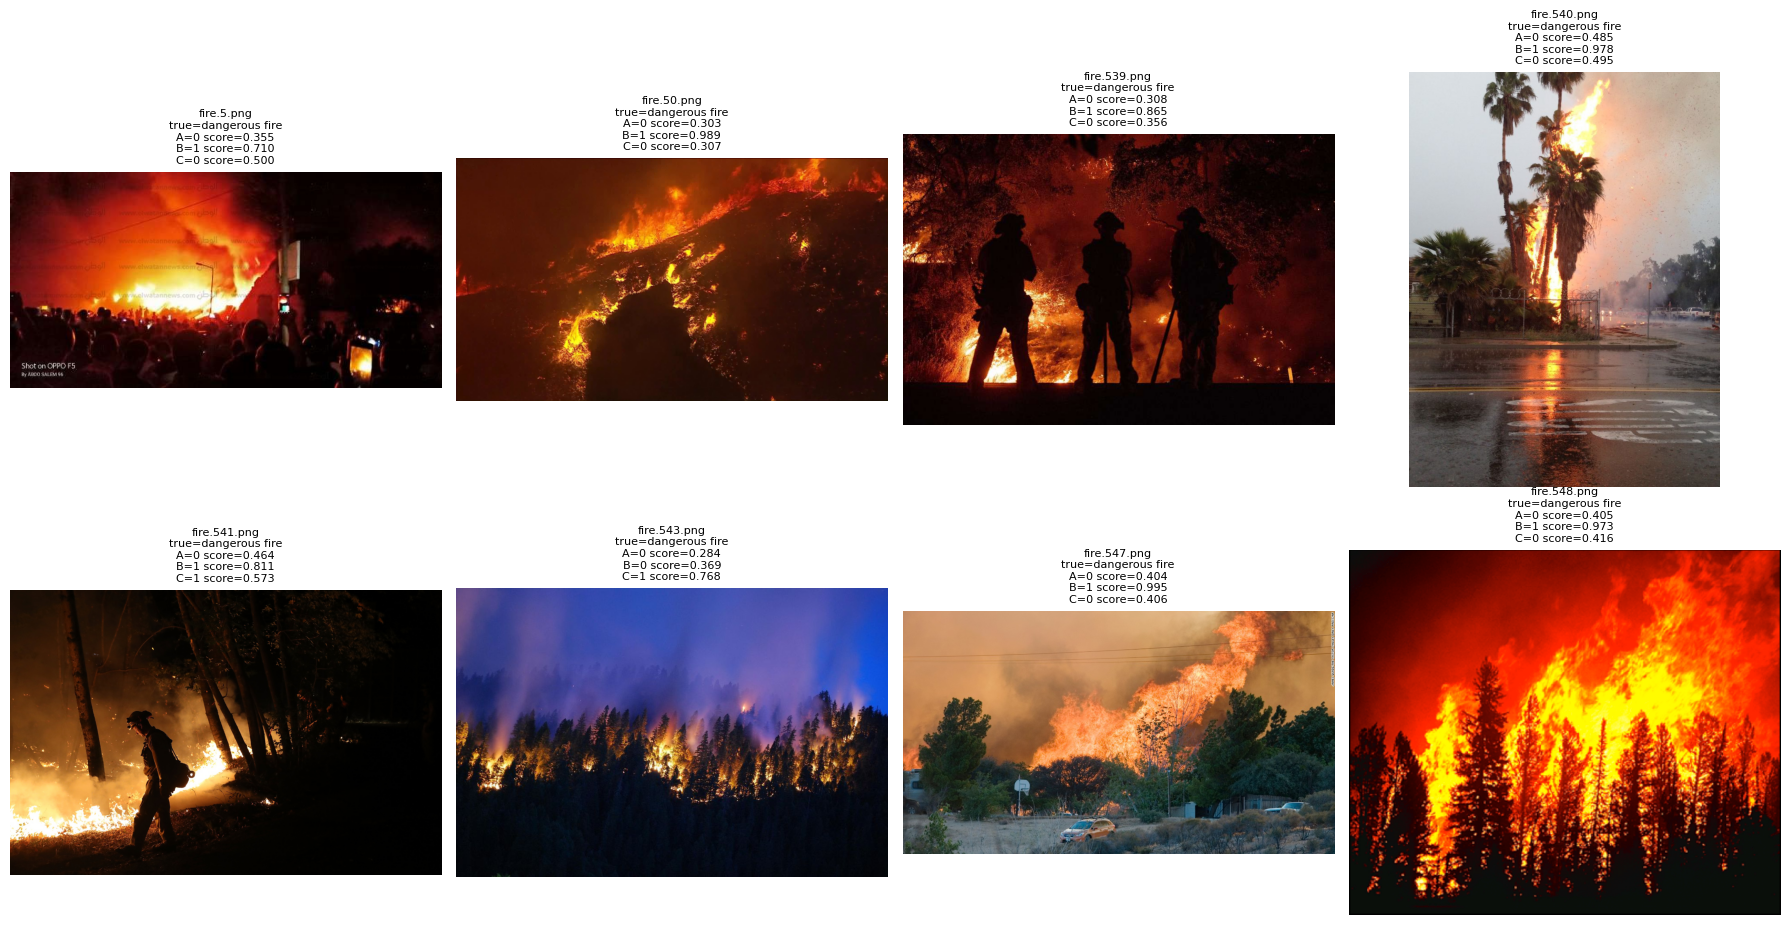

In [14]:
# Cell 14: Visual sample of disagreements
def show_disagreements(df, n=8, threshold=DECISION_THRESHOLD):
    temp = df.copy()
    pred_cols = []
    for idx, (model_name, score_col) in enumerate(MODEL_SPECS):
        pred_col = f'pred_{idx}'
        temp[pred_col] = predict_from_scores(temp[score_col], threshold)
        pred_cols.append(pred_col)
    disagreements = temp[temp[pred_cols].nunique(axis=1) > 1].head(n)

    if disagreements.empty:
        print('No disagreements among Model A, Model B, and Model C at this threshold.')
        return

    cols = min(4, len(disagreements))
    rows = int(np.ceil(len(disagreements) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.8 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, disagreements.iterrows()):
        img = Image.open(row['path']).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        model_lines = [
            f"{model_name.split(':')[0][-1]}={row[f'pred_{idx}']} score={row[score_col]:.3f}"
            for idx, (model_name, score_col) in enumerate(MODEL_SPECS)
        ]
        ax.set_title(
            f"{row['filename']}\ntrue={row['true_label_name']}\n"
            + "\n".join(model_lines),
            fontsize=8,
        )

    for ax in axes[len(disagreements):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

show_disagreements(results_df)

In [15]:
# Cell 15: Save comparison outputs to Google Drive
results_csv = os.path.join(OUTPUT_DIR, 'model_comparison_per_image.csv')
summary_csv = os.path.join(OUTPUT_DIR, 'model_comparison_summary_default_threshold.csv')
sweep_csv = os.path.join(OUTPUT_DIR, 'model_comparison_threshold_sweep.csv')
best_f1_csv = os.path.join(OUTPUT_DIR, 'model_comparison_best_f1.csv')
best_f2_csv = os.path.join(OUTPUT_DIR, 'model_comparison_best_f2.csv')

results_df.to_csv(results_csv, index=False)
summary_df.to_csv(summary_csv, index=False)
sweep_df.to_csv(sweep_csv, index=False)
best_f1_df.to_csv(best_f1_csv, index=False)
best_f2_df.to_csv(best_f2_csv, index=False)

print(f'Per-image results: {results_csv}')
print(f'Default-threshold summary: {summary_csv}')
print(f'Treshold sweep: {sweep_csv}')
print(f'Best-F1 thresholds: {best_f1_csv}')
print(f'Best-F2 thresholds: {best_f2_csv}')

Per-image results: /content/drive/MyDrive/model_comparison_outputs/model_comparison_per_image.csv
Default-threshold summary: /content/drive/MyDrive/model_comparison_outputs/model_comparison_summary_default_threshold.csv
Treshold sweep: /content/drive/MyDrive/model_comparison_outputs/model_comparison_threshold_sweep.csv
Best-F1 thresholds: /content/drive/MyDrive/model_comparison_outputs/model_comparison_best_f1.csv
Best-F2 thresholds: /content/drive/MyDrive/model_comparison_outputs/model_comparison_best_f2.csv


## How to decide which model is better

Use the tables and plots together:

- Prefer the model with the higher **F1-score** when precision and recall matter equally.
- Prefer the model with the higher **F2-score** when missing dangerous fire is more costly, because F2 weights recall more than precision.
- If low false positives are the priority, compare **false-positive rate** at acceptable false-negative rates.
- Check **false negatives** carefully: these are dangerous-fire images the model missed.
- In the DET curve, the better model is generally closer to the bottom-left. If curves cross, choose the operating threshold that matches your acceptable false-positive vs false-negative tradeoff.